# Phase 1 Project: Restaurant Tips — Data Exploration
**Course skills used:** Python, Pandas, Data Visualization (Kaggle Micro-Courses)

**Goal:** Load a real dataset, explore it with pandas, and create 3 charts to find patterns — the Phase 1 deliverable from my AI Summer Study Plan.

**Dataset:** `tips.csv` — 244 records of restaurant bills, tips, and customer info (a classic beginner dataset, similar to what's used in the Kaggle courses).

## 1. Load the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("tips.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. Explore the Data
Basic pandas exploration: shape, data types, and summary statistics.

In [2]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
df.describe()

Shape: (244, 7)

total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object



,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [3]:
# Calculate tip percentage — a derived column using pandas
df["tip_pct"] = (df["tip"] / df["total_bill"]) * 100

# Group by day to see average bill and tip per day
df.groupby("day")[["total_bill", "tip", "tip_pct"]].mean().round(2)

,total_bill,tip,tip_pct
day,,,
Fri,17.15,2.73,16.99
Sat,20.44,2.99,15.32
Sun,21.41,3.26,16.69
Thur,17.68,2.77,16.13


## 3. Chart 1 — Bar Chart: Average Bill by Day of the Week

/tmp/ipykernel_581/3029809975.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="day", y="total_bill", order=["Thur","Fri","Sat","Sun"], errorbar=None, palette="Blues_d")


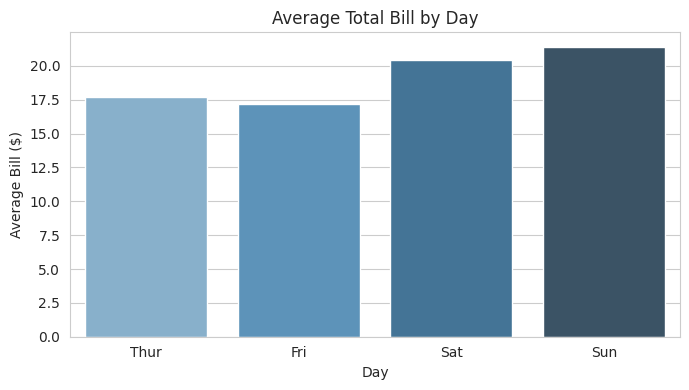

In [4]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="day", y="total_bill", order=["Thur","Fri","Sat","Sun"], errorbar=None, palette="Blues_d")
plt.title("Average Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Bill ($)")
plt.tight_layout()
plt.savefig("chart1_bar_bill_by_day.png", dpi=150)
plt.show()

## 4. Chart 2 — Scatter Plot: Total Bill vs Tip

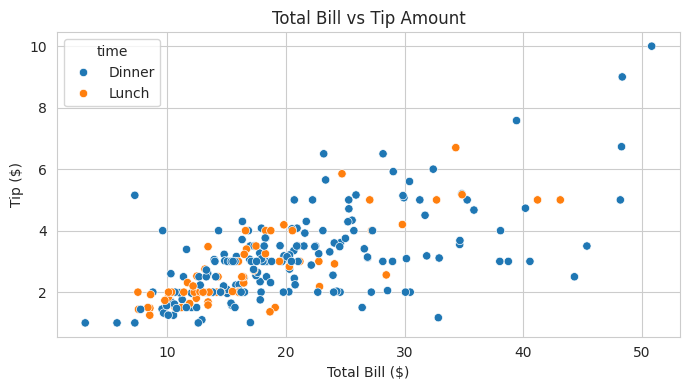

In [5]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="time")
plt.title("Total Bill vs Tip Amount")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.tight_layout()
plt.savefig("chart2_scatter_bill_vs_tip.png", dpi=150)
plt.show()

## 5. Chart 3 — Histogram: Distribution of Tip Percentage

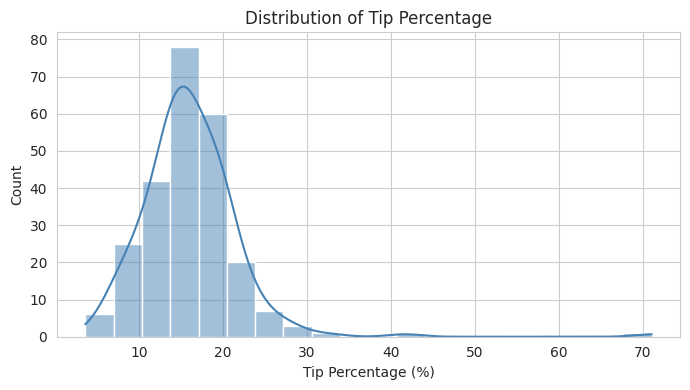

In [6]:
plt.figure(figsize=(7,4))
sns.histplot(df["tip_pct"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of Tip Percentage")
plt.xlabel("Tip Percentage (%)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("chart3_hist_tip_pct.png", dpi=150)
plt.show()

## 6. Findings

- **Saturday and Sunday** have the highest average bills — weekend dinners bring in more per table.
- There's a clear **positive relationship** between total bill and tip amount — bigger bills generally mean bigger tips, though the rate varies.
- Most customers tip in the **15–20% range**, with a noticeable right-skew from a handful of very generous tippers.

## Skills demonstrated
- **Python:** variables, functions (implicit via pandas methods), working with an external library
- **Pandas:** `read_csv`, `.describe()`, `.groupby()`, creating a derived column
- **Data Visualization:** bar chart, scatter plot, and histogram using Seaborn, each styled and labeled

This satisfies the Phase 1 deliverable: *"Load dataset, explore data, create 3 charts."*